# M4.Ex2: Penguins Classification (PyCaret)

### Name: Shaima Alqahtani

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex2_pycaret_classification.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **Palmer Penguins Dataset** below:

- [**🚀 Classification**](https://pycaret.gitbook.io/docs/get-started/quickstart#classification)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## Palmer Penguins Dataset

The goal of palmer penguins is to provide a great dataset for data exploration & visualization, as an alternative to iris.

The data contains 344 penguins. There are 3 different species of penguins in this dataset, collected from 3 islands in the Palmer Archipelago, Antarctica.

- Features: `4` numerical, `2` categorical
- Target: `species` (Categorical / 3 classes)
- Size: `344` samples
- Source: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/)

### Load the data

In [34]:
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Experiments

1. **First experiment**:
    - X = Flipper Length (numerical) & Bill Length (numerical)
    - y = Species (categorical)
2. **Second experiment**:
    - X = Weights (numerical) & Species (categorical)
    - y = Sex (categroical)
3. **Third experiment**:
    - X = `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
    - y = Sex and Species (multi-label classification)

### A1: first experiment

In [35]:
# Setup PyCaret
from pycaret.classification import *

df1 = penguins.dropna()

exp1 = setup(
    data=df1[['flipper_length_mm', 'bill_length_mm', 'species']],
    target='species',
    session_id=123,
    verbose=True
)


,Description,Value
0,Session id,123
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(333, 3)"
5,Transformed data shape,"(333, 3)"
6,Transformed train set shape,"(233, 3)"
7,Transformed test set shape,"(100, 3)"
8,Numeric features,2
9,Preprocess,True


In [36]:
# Compare models
best1 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9784,0.9900,0.9784,0.9812,0.9783,0.9664,0.9678,0.0790
lr,Logistic Regression,0.9743,0.0000,0.9743,0.9771,0.9732,0.9594,0.9614,0.7240
dt,Decision Tree Classifier,0.9699,0.9777,0.9699,0.9738,0.9697,0.9531,0.9550,0.0180
gbc,Gradient Boosting Classifier,0.9699,0.0000,0.9699,0.9742,0.9700,0.9534,0.9553,0.1110
lightgbm,Light Gradient Boosting Machine,0.9699,0.9937,0.9699,0.9749,0.9701,0.9533,0.9555,0.1700
et,Extra Trees Classifier,0.9656,0.9901,0.9656,0.9685,0.9652,0.9462,0.9478,0.0650
qda,Quadratic Discriminant Analysis,0.9612,0.0000,0.9612,0.9626,0.9598,0.9388,0.9405,0.0120
lda,Linear Discriminant Analysis,0.9612,0.0000,0.9612,0.9649,0.9595,0.9387,0.9415,0.0140
knn,K Neighbors Classifier,0.9571,0.9814,0.9571,0.9609,0.9544,0.9319,0.9349,0.0230
ridge,Ridge Classifier,0.9571,0.0000,0.9571,0.9607,0.9552,0.9320,0.9347,0.0130


In [37]:
# Create the best model
model1 = create_model(best1)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9583,1.0000,0.9583,0.9630,0.9586,0.9350,0.9375
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,0.9565,1.0000,0.9565,0.9638,0.9570,0.9329,0.9357
6,0.9565,0.9988,0.9565,0.9605,0.9551,0.9313,0.9343
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,0.9565,0.9578,0.9565,0.9638,0.9574,0.9333,0.9361


In [38]:
# Tune the model
tuned1 = tune_model(model1)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9583,0.9671,0.9583,0.9630,0.9586,0.9350,0.9375
1,0.9583,1.0000,0.9583,0.9653,0.9588,0.9350,0.9375
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,0.9565,1.0000,0.9565,0.9638,0.9570,0.9329,0.9357
6,0.9130,0.9885,0.9130,0.9379,0.9155,0.8686,0.8787
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,0.9565,0.9693,0.9565,0.9638,0.9574,0.9333,0.9361


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


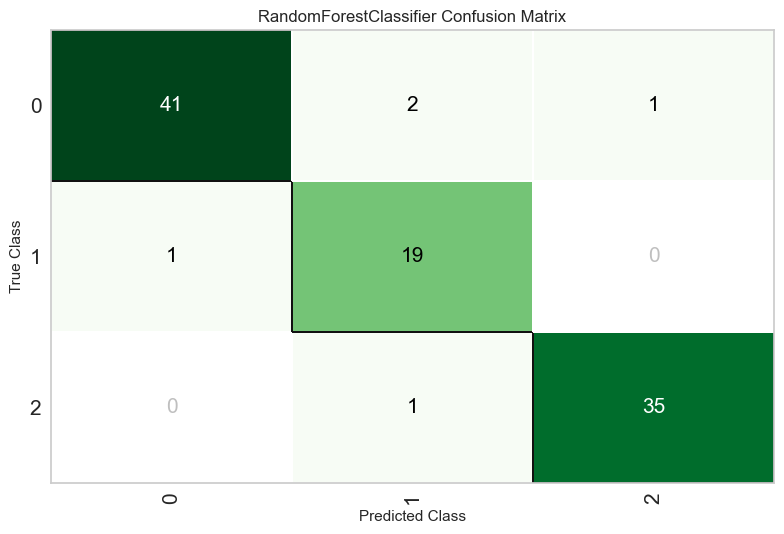

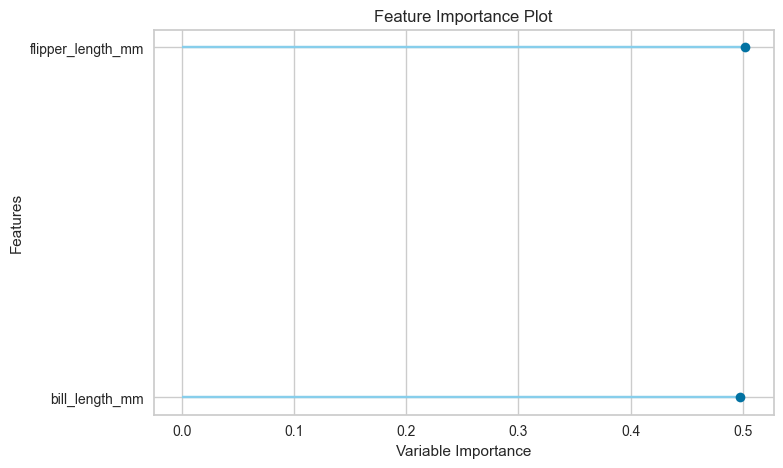

In [39]:
# Analyze model
plot_model(tuned1, plot='confusion_matrix')
plot_model(tuned1, plot='feature')

In [40]:
# Predict
pred1 = predict_model(tuned1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9500,0.9794,0.9500,0.9523,0.9505,0.9221,0.9227


In [41]:
# Save the model
save_model(tuned1, "penguins_exp1_model")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['flipper_length_mm',
                                              'bill_length_mm'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               miss...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',

### A2: Second experiment

In [42]:
# Setup PyCaret
df2 = penguins.dropna()

exp2 = setup(
    data=df2[['body_mass_g', 'species', 'sex']],
    target='sex',
    session_id=123,
    verbose=True
)

,Description,Value
0,Session id,123
1,Target,sex
2,Target type,Binary
3,Target mapping,"Female: 0, Male: 1"
4,Original data shape,"(333, 3)"
5,Transformed data shape,"(333, 5)"
6,Transformed train set shape,"(233, 5)"
7,Transformed test set shape,"(100, 5)"
8,Numeric features,1
9,Categorical features,1


In [43]:
# compare models
best2 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8627,0.9139,0.8627,0.8683,0.8617,0.7249,0.7305,0.0390
ridge,Ridge Classifier,0.8591,0.9459,0.8591,0.8623,0.8586,0.7176,0.7209,0.0170
lda,Linear Discriminant Analysis,0.8551,0.9423,0.8551,0.8594,0.8544,0.7097,0.7141,0.0170
lr,Logistic Regression,0.8543,0.9344,0.8543,0.8587,0.8539,0.7083,0.7127,0.0250
et,Extra Trees Classifier,0.8373,0.8657,0.8373,0.8489,0.8354,0.6737,0.6852,0.0600
dt,Decision Tree Classifier,0.8371,0.8546,0.8371,0.8467,0.8352,0.6737,0.6832,0.0170
lightgbm,Light Gradient Boosting Machine,0.8330,0.9314,0.8330,0.8433,0.8306,0.6647,0.6752,0.0580
rf,Random Forest Classifier,0.8288,0.9043,0.8288,0.8357,0.8273,0.6569,0.6639,0.0730
gbc,Gradient Boosting Classifier,0.8201,0.9197,0.8201,0.8269,0.8184,0.6392,0.6461,0.0390
qda,Quadratic Discriminant Analysis,0.8031,0.8902,0.8031,0.8397,0.7950,0.6028,0.6389,0.0170


In [44]:
# Create the best model
model2 = create_model(best2)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9167,0.9271,0.9167,0.9167,0.9167,0.8333,0.8333
1,0.8333,0.9236,0.8333,0.8333,0.8333,0.6667,0.6667
2,0.8333,0.8750,0.8333,0.8429,0.8322,0.6667,0.6761
3,0.8261,0.9508,0.8261,0.8261,0.8261,0.6515,0.6515
4,0.7826,0.8258,0.7826,0.8011,0.7775,0.5594,0.5800
5,0.8696,0.9280,0.8696,0.8719,0.8691,0.7376,0.7405
6,0.9565,0.9242,0.9565,0.9599,0.9564,0.9125,0.9161
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,0.8261,0.9167,0.8261,0.8261,0.8261,0.6515,0.6515


In [45]:
# Tune the model
tuned2 = tune_model(model2)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9167,0.9236,0.9167,0.9167,0.9167,0.8333,0.8333
1,0.8333,0.8785,0.8333,0.8333,0.8333,0.6667,0.6667
2,0.7917,0.8715,0.7917,0.8111,0.7884,0.5833,0.6025
3,0.8696,0.8561,0.8696,0.8719,0.8691,0.7376,0.7405
4,0.8261,0.7765,0.8261,0.8351,0.8241,0.6489,0.6591
5,0.8696,0.9129,0.8696,0.8719,0.8691,0.7376,0.7405
6,0.9565,0.9242,0.9565,0.9599,0.9564,0.9125,0.9161
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,0.8261,0.8485,0.8261,0.8261,0.8261,0.6515,0.6515


Fitting 10 folds for each of 10 candidates, totalling 100 fits


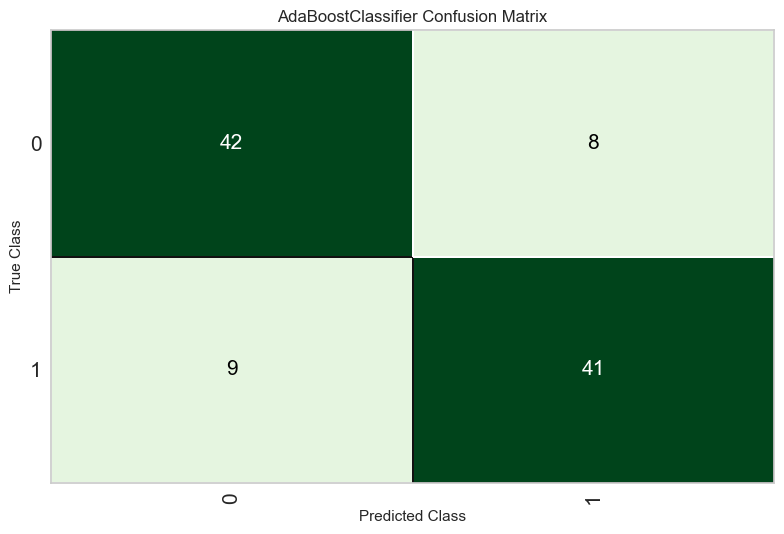

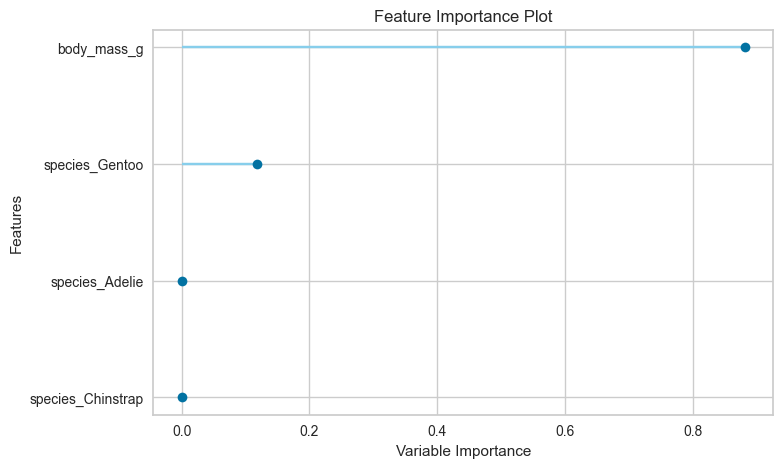

In [46]:
# Analyze model
plot_model(tuned2, plot='confusion_matrix')
plot_model(tuned2, plot='feature')

In [47]:
# Predict
pred2 = predict_model(tuned2)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8300,0.8412,0.8300,0.8301,0.8300,0.6600,0.6601


In [48]:
# Save the model
save_model(tuned2, "penguins_exp2_model")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=['body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy...
                  TransformerWrapper(exclude=None, include=['species'],
                                     transformer=OneHotEncoder(cols=['species'],
                

### A3: Third experiment

In [49]:
# Setup PyCaret
df = penguins.dropna().copy()

df['combined'] = df['sex'] + "_" + df['species']

exp3 = setup(
    data=df[['island', 'bill_length_mm', 'bill_depth_mm',
             'flipper_length_mm', 'body_mass_g', 'combined']],
    target='combined',
    session_id=123,
    verbose=True
)


,Description,Value
0,Session id,123
1,Target,combined
2,Target type,Multiclass
3,Target mapping,"Female_Adelie: 0, Female_Chinstrap: 1, Female_Gentoo: 2, Male_Adelie: 3, Male_Chinstrap: 4, Male_Gentoo: 5"
4,Original data shape,"(333, 6)"
5,Transformed data shape,"(333, 8)"
6,Transformed train set shape,"(233, 8)"
7,Transformed test set shape,"(100, 8)"
8,Numeric features,4
9,Categorical features,1


In [50]:
# Compare models
best3 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8971,0.9909,0.8971,0.9145,0.8945,0.8739,0.8778,0.1180
et,Extra Trees Classifier,0.8967,0.9936,0.8967,0.9092,0.8917,0.8736,0.8779,0.1360
lightgbm,Light Gradient Boosting Machine,0.8933,0.9850,0.8933,0.9090,0.8895,0.8695,0.8738,0.3580
gbc,Gradient Boosting Classifier,0.8928,0.0000,0.8928,0.9158,0.8904,0.8689,0.8742,0.4760
lda,Linear Discriminant Analysis,0.8924,0.0000,0.8924,0.9138,0.8899,0.8683,0.8736,0.0330
ridge,Ridge Classifier,0.8409,0.0000,0.8409,0.8580,0.8331,0.8047,0.8108,0.0290
dt,Decision Tree Classifier,0.8281,0.8972,0.8281,0.8478,0.8221,0.7903,0.7963,0.0320
lr,Logistic Regression,0.8071,0.0000,0.8071,0.8106,0.7966,0.7638,0.7701,0.1180
nb,Naive Bayes,0.7808,0.9770,0.7808,0.8833,0.7889,0.7381,0.7594,0.0370
knn,K Neighbors Classifier,0.6661,0.8747,0.6661,0.6801,0.6448,0.5889,0.6012,0.0510


In [51]:
# Create the best model
model3 = create_model(best3)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9167,0.9968,0.9167,0.9226,0.9141,0.8972,0.8992
1,0.8333,0.9978,0.8333,0.8819,0.8218,0.7983,0.8086
2,0.9167,0.9950,0.9167,0.9405,0.9171,0.8987,0.9045
3,0.9130,0.9667,0.9130,0.9290,0.9119,0.8940,0.8982
4,0.9565,0.9952,0.9565,0.9638,0.9561,0.9470,0.9492
5,0.8696,0.9950,0.8696,0.8841,0.8667,0.8388,0.8408
6,0.8696,0.9906,0.8696,0.8768,0.8691,0.8395,0.8415
7,0.9130,0.9824,0.9130,0.9348,0.9097,0.8930,0.8972
8,0.8261,0.9890,0.8261,0.8478,0.8221,0.7855,0.7892


In [52]:
# Tune the model
tuned3 = tune_model(model3)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9583,0.9978,0.9583,0.9653,0.9561,0.9487,0.9508
1,0.7917,0.9935,0.7917,0.8333,0.7806,0.7479,0.7559
2,0.9167,0.9855,0.9167,0.9405,0.9171,0.8987,0.9045
3,0.9130,0.9668,0.9130,0.9290,0.9119,0.8940,0.8982
4,0.8696,0.9907,0.8696,0.8928,0.8655,0.8425,0.8483
5,0.8696,0.9859,0.8696,0.8841,0.8667,0.8388,0.8408
6,0.9130,0.9859,0.9130,0.9348,0.9138,0.8935,0.8977
7,0.9130,0.9824,0.9130,0.9348,0.9097,0.8930,0.8972
8,0.8696,0.9934,0.8696,0.8986,0.8651,0.8392,0.8451


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [53]:
# Predict
pred3 = predict_model(tuned3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9500,0.9943,0.9500,0.9543,0.9498,0.9389,0.9399


In [54]:
# Split combined prediction into two columns
pred3[['pred_sex', 'pred_species']] = pred3['prediction_label'].str.split('_', expand=True)
pred3

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,combined,prediction_label,prediction_score,pred_sex,pred_species
97,Dream,40.299999,18.500000,196.0,4350.0,Male_Adelie,Male_Adelie,0.6434,Male,Adelie
266,Biscoe,45.500000,13.900000,210.0,4200.0,Female_Gentoo,Female_Gentoo,0.8659,Female,Gentoo
137,Dream,40.200001,20.100000,200.0,3975.0,Male_Adelie,Male_Adelie,0.6780,Male,Adelie
195,Dream,45.500000,17.000000,196.0,3500.0,Female_Chinstrap,Female_Chinstrap,0.7462,Female,Chinstrap
6,Torgersen,38.900002,17.799999,181.0,3625.0,Female_Adelie,Female_Adelie,0.8024,Female,Adelie
...,...,...,...,...,...,...,...,...,...,...
304,Biscoe,44.900002,13.800000,212.0,4750.0,Female_Gentoo,Female_Gentoo,0.9269,Female,Gentoo
174,Dream,43.200001,16.600000,187.0,2900.0,Female_Chinstrap,Female_Chinstrap,0.7524,Female,Chinstrap
171,Dream,49.200001,18.200001,195.0,4400.0,Male_Chinstrap,Male_Chinstrap,0.5690,Male,Chinstrap
44,Dream,37.000000,16.900000,185.0,3000.0,Female_Adelie,Female_Adelie,0.8199,Female,Adelie


In [55]:
# Save the model
save_model(tuned3, "penguins_exp3_model")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['bill_length_mm', 'bill_depth_mm',
                                              'flipper_length_mm',
                                              'body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,...
                  RandomForestClassifier(bootstrap=False, ccp_alpha=0.0,
                                         class_weight='balanced_subsample',
                                         criterion='gini', max_depth=6,
        